# 03 — Exploratory Data Analysis (EDA)

**Objective:** Explore trends, distributions, and outliers in the cleaned dataset — with a focus on understanding **product return patterns** in e-commerce.

**Input:** `data/processed/cleaned_online_sales.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv('../data/processed/cleaned_online_sales.csv', parse_dates=['InvoiceDate'])
print(f'Loaded {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Loaded 44,804 rows, 23 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,...,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority,Revenue,IsReturn,OrderMonth,OrderYear,OrderDayOfWeek,OrderHour
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00:00,1.71,37039,Australia,0.47,Bank Transfer,...,Not Returned,UPS,London,Medium,34.44,0,1,2020,Wednesday,0
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00:00,41.25,19144,Spain,0.19,PayPal,...,Not Returned,UPS,Rome,Medium,601.43,0,1,2020,Wednesday,1
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00:00,29.11,50472,Germany,0.35,Bank Transfer,...,Returned,UPS,Berlin,High,927.15,1,1,2020,Wednesday,2
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00:00,76.68,96586,Netherlands,0.14,PayPal,...,Not Returned,Royal Mail,Rome,Low,923.23,0,1,2020,Wednesday,3
4,744167,SKU_1006,Office Chair,47,2020-01-01 05:00:00,70.16,53887,Sweden,0.48,Credit Card,...,Not Returned,DHL,London,Medium,1714.71,0,1,2020,Wednesday,5


## 1. Return Rate Overview
What proportion of orders are returned?

/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/3212182445.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=return_counts.index, y=return_counts.values, ax=axes[0], palette=['#2ecc71', '#e74c3c'])


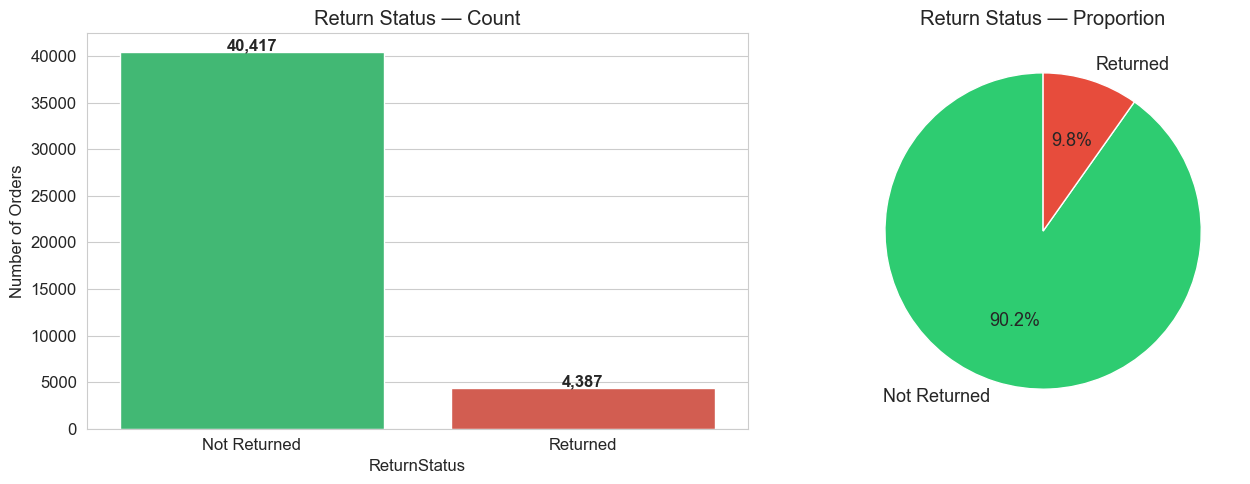

Overall return rate: 9.79%


In [31]:
return_counts = df['ReturnStatus'].value_counts()
return_pct = (return_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count bar
sns.barplot(x=return_counts.index, y=return_counts.values, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Return Status — Count')
axes[0].set_ylabel('Number of Orders')
for i, v in enumerate(return_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(return_counts, labels=return_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Return Status — Proportion')

plt.tight_layout()
plt.show()

print(f'Overall return rate: {df["IsReturn"].mean()*100:.2f}%')

## 2. Revenue Impact of Returns
How much revenue is lost to returned orders?

In [32]:
rev_by_status = df.groupby('ReturnStatus')['Revenue'].agg(['sum', 'mean', 'count'])
rev_by_status.columns = ['Total Revenue', 'Avg Revenue per Order', 'Order Count']
rev_by_status['Total Revenue'] = rev_by_status['Total Revenue'].round(2)
rev_by_status['Avg Revenue per Order'] = rev_by_status['Avg Revenue per Order'].round(2)
display(rev_by_status)

returned_rev = rev_by_status.loc['Returned', 'Total Revenue']
total_rev = rev_by_status['Total Revenue'].sum()
print(f'\nRevenue at risk from returns: ${returned_rev:,.2f} ({returned_rev/total_rev*100:.1f}% of total)')

,Total Revenue,Avg Revenue per Order,Order Count
ReturnStatus,,,
Not Returned,38221940.31,945.69,40417
Returned,4093258.70,933.04,4387



Revenue at risk from returns: $4,093,258.70 (9.7% of total)


## 3. Category-wise Return Analysis
Which product categories have the highest return rates?

,total_orders,returns,return_rate,avg_price,total_revenue
Category,,,,,
Furniture,9074,910,10.03,50.575854,8571143.20
Stationery,8957,885,9.88,50.253857,8411054.07
Apparel,8891,867,9.75,50.774799,8400511.94
Electronics,8956,868,9.69,50.723537,8458944.71
Accessories,8926,857,9.60,50.787941,8473545.09


/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/3181332651.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_return.reset_index(), x='return_rate', y='Category', ax=axes[0], palette='Reds_r')
/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/3181332651.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_return.reset_index(), x='total_revenue', y='Category', ax=axes[1], palette='Blues_r')


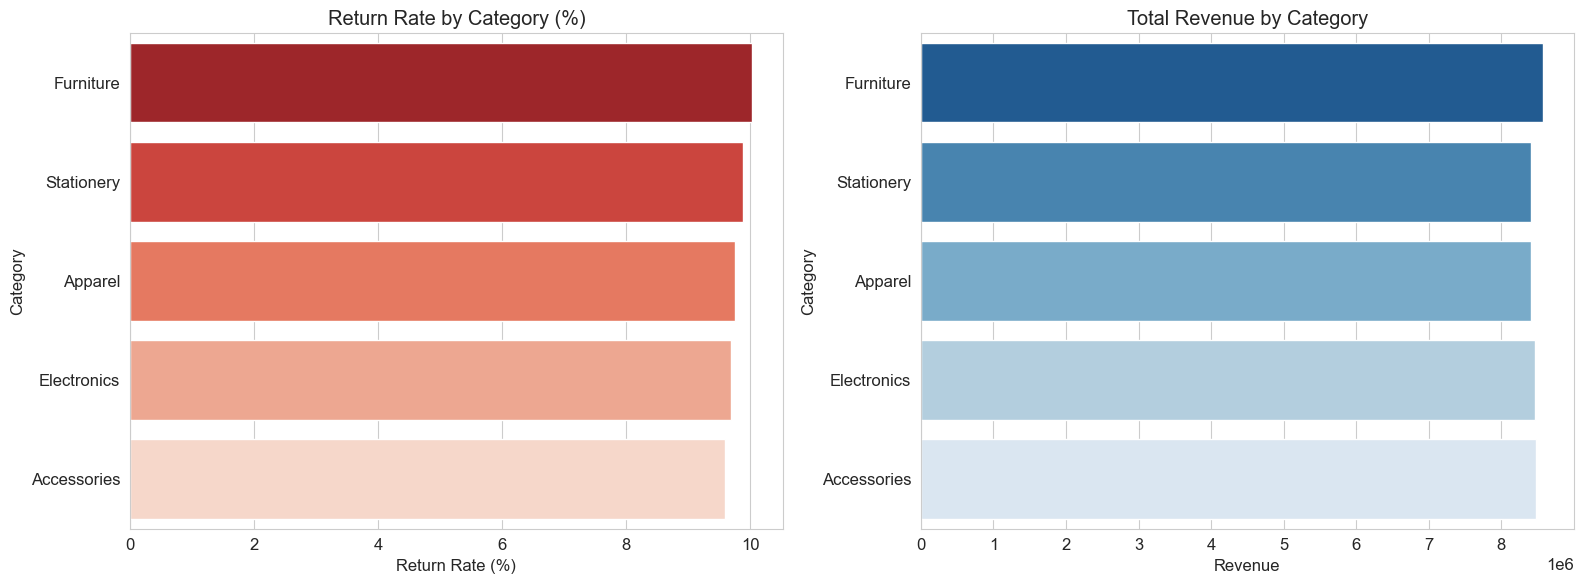

In [33]:
cat_return = df.groupby('Category').agg(
    total_orders=('IsReturn', 'count'),
    returns=('IsReturn', 'sum'),
    return_rate=('IsReturn', 'mean'),
    avg_price=('UnitPrice', 'mean'),
    total_revenue=('Revenue', 'sum')
).sort_values('return_rate', ascending=False)
cat_return['return_rate'] = (cat_return['return_rate'] * 100).round(2)
display(cat_return)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=cat_return.reset_index(), x='return_rate', y='Category', ax=axes[0], palette='Reds_r')
axes[0].set_title('Return Rate by Category (%)')
axes[0].set_xlabel('Return Rate (%)')

sns.barplot(data=cat_return.reset_index(), x='total_revenue', y='Category', ax=axes[1], palette='Blues_r')
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Revenue')
plt.tight_layout()
plt.show()

## 4. Product-level Return Analysis
Which specific products are returned the most?

Top 10 Products by Number of Returns:


,total_orders,returns,return_rate,total_revenue
Description,,,,
Notebook,4015,421,10.49,3802157.91
Wall Clock,4159,419,10.07,3894783.08
USB Cable,4130,417,10.10,3883871.41
Blue Pen,4036,404,10.01,3822013.77
T-shirt,4050,403,9.95,3802392.08
Backpack,4122,400,9.70,3859457.42
Desk Lamp,4103,392,9.55,3890642.44
Wireless Mouse,3975,388,9.76,3807658.12
White Mug,4091,385,9.41,3950316.33


/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/3756266679.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prods, x='returns', y='Description', palette='OrRd_r')


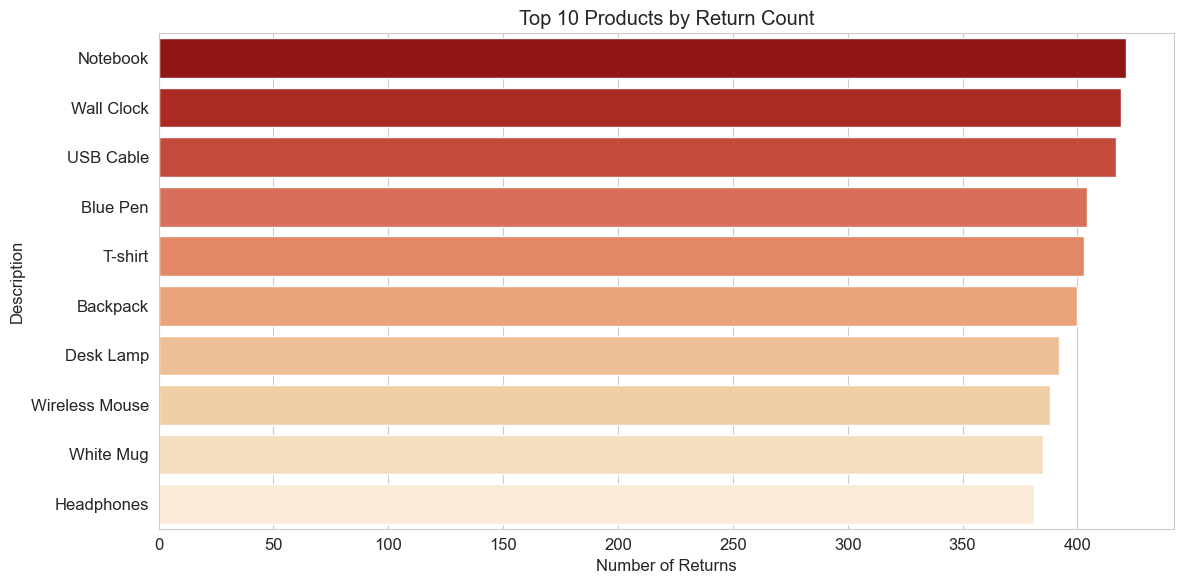

In [6]:
prod_return = df.groupby('Description').agg(
    total_orders=('IsReturn', 'count'),
    returns=('IsReturn', 'sum'),
    return_rate=('IsReturn', 'mean'),
    total_revenue=('Revenue', 'sum')
).sort_values('returns', ascending=False)
prod_return['return_rate'] = (prod_return['return_rate'] * 100).round(2)

print('Top 10 Products by Number of Returns:')
display(prod_return.head(10))

plt.figure(figsize=(12, 6))
top_prods = prod_return.head(10).reset_index()
sns.barplot(data=top_prods, x='returns', y='Description', palette='OrRd_r')
plt.title('Top 10 Products by Return Count')
plt.xlabel('Number of Returns')
plt.tight_layout()
plt.show()

## 5. Country-wise Return Analysis
Do return rates vary by geography?

,total_orders,returns,return_rate,total_revenue
Country,,,,
Australia,3698,390,10.55,3440394.86
Germany,3763,387,10.28,3548894.26
Belgium,3745,371,9.91,3628107.56
United Kingdom,3735,369,9.88,3539162.17
Sweden,3771,372,9.86,3555065.84
United States,3690,363,9.84,3609185.21
Italy,3642,358,9.83,3478254.18
France,3820,373,9.76,3577957.99
Portugal,3747,361,9.63,3521324.33


/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/3749325671.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_return.reset_index(), x='return_rate', y='Country', palette='RdYlGn_r')


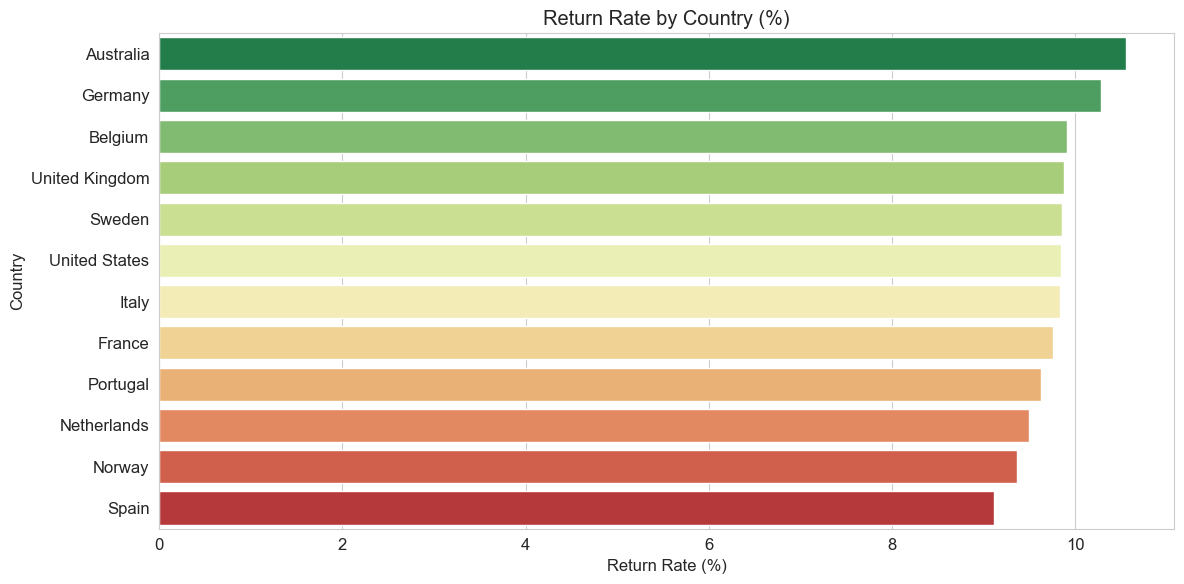

In [34]:
country_return = df.groupby('Country').agg(
    total_orders=('IsReturn', 'count'),
    returns=('IsReturn', 'sum'),
    return_rate=('IsReturn', 'mean'),
    total_revenue=('Revenue', 'sum')
).sort_values('return_rate', ascending=False)
country_return['return_rate'] = (country_return['return_rate'] * 100).round(2)

display(country_return)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_return.reset_index(), x='return_rate', y='Country', palette='RdYlGn_r')
plt.title('Return Rate by Country (%)')
plt.xlabel('Return Rate (%)')
plt.tight_layout()
plt.show()

## 6. Sales Channel — Online vs In-store
Does the sales channel affect return likelihood?

,total_orders,returns,return_rate
SalesChannel,,,
In-store,22284,2194,9.85
Online,22520,2193,9.74


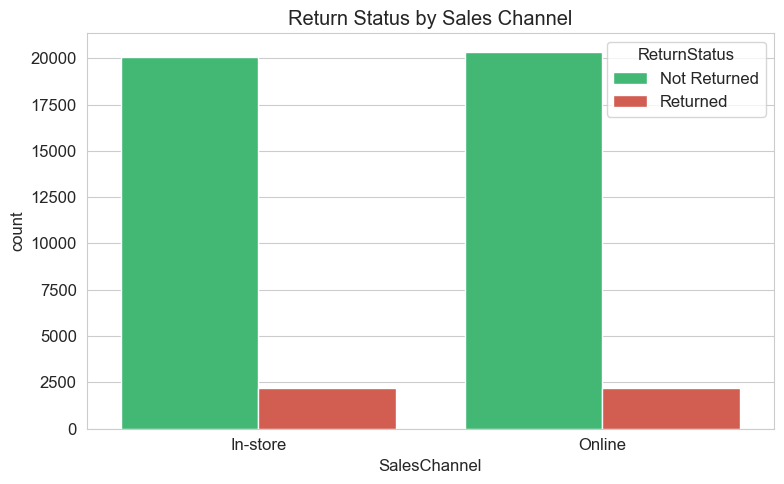

In [35]:
channel_return = df.groupby('SalesChannel').agg(
    total_orders=('IsReturn', 'count'),
    returns=('IsReturn', 'sum'),
    return_rate=('IsReturn', 'mean')
)
channel_return['return_rate'] = (channel_return['return_rate'] * 100).round(2)
display(channel_return)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='SalesChannel', hue='ReturnStatus', palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Return Status by Sales Channel')
plt.tight_layout()
plt.show()

## 7. Payment Method vs Returns

,Total Orders,Returns,Return Rate
PaymentMethod,,,
Bank Transfer,15086,1498,9.93
Credit Card,14907,1449,9.72
PayPal,14811,1440,9.72


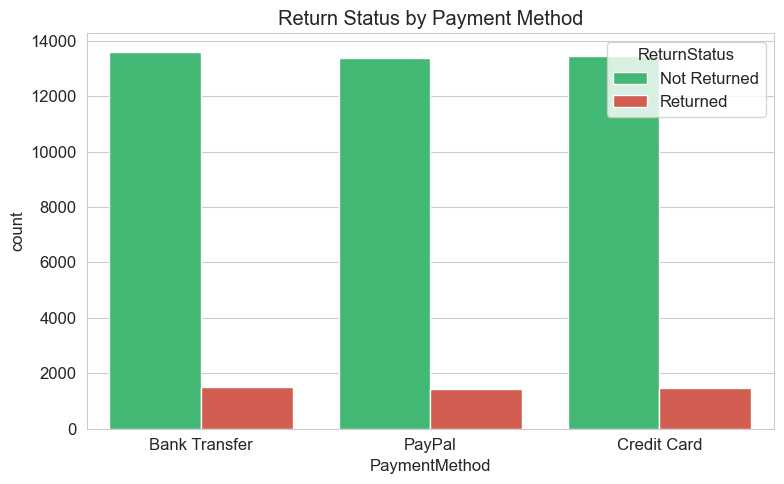

In [9]:
pay_return = df.groupby('PaymentMethod')['IsReturn'].agg(['count', 'sum', 'mean'])
pay_return.columns = ['Total Orders', 'Returns', 'Return Rate']
pay_return['Return Rate'] = (pay_return['Return Rate'] * 100).round(2)
pay_return = pay_return.sort_values('Return Rate', ascending=False)
display(pay_return)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='PaymentMethod', hue='ReturnStatus', palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Return Status by Payment Method')
plt.tight_layout()
plt.show()

## 8. Price & Discount Distribution — Returned vs Not Returned
Are returned products priced differently? Do discounts affect returns?

/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/2212985661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ReturnStatus', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/2212985661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ReturnStatus', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/2212985661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Retur

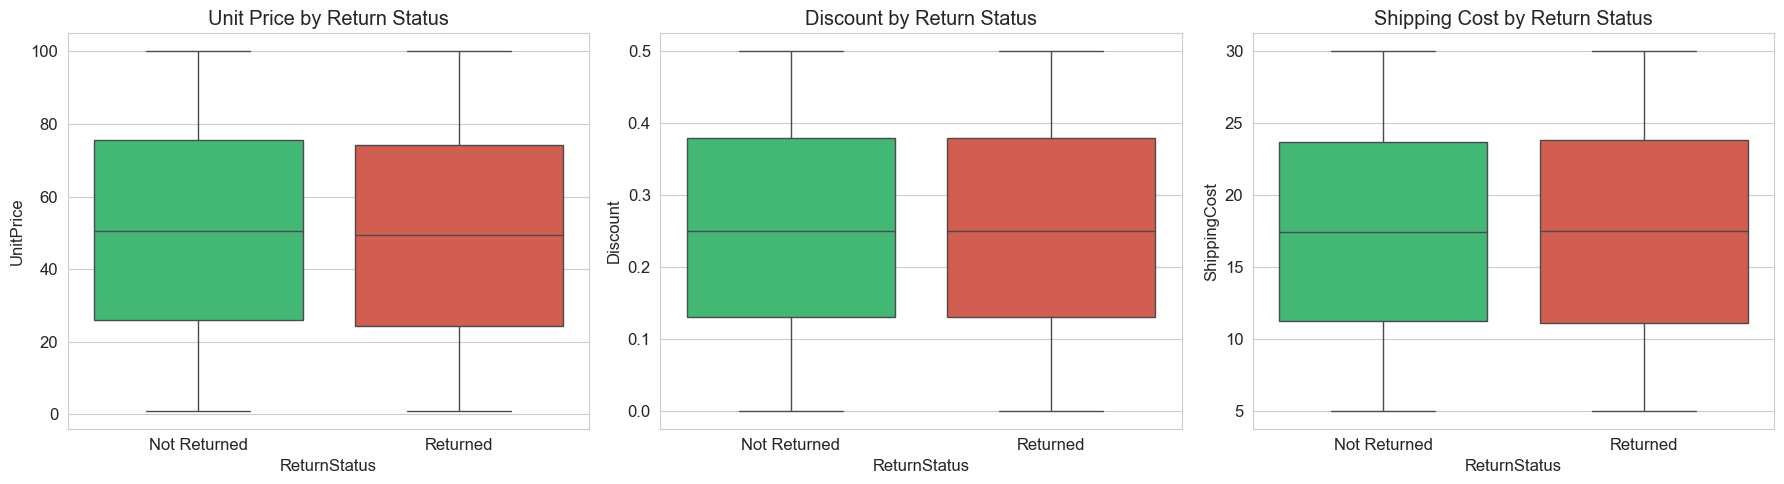

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, ['UnitPrice', 'Discount', 'ShippingCost'],
                          ['Unit Price', 'Discount', 'Shipping Cost']):
    sns.boxplot(data=df, x='ReturnStatus', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{title} by Return Status')

plt.tight_layout()
plt.show()

In [36]:
# Compare means
compare = df.groupby('ReturnStatus')[['UnitPrice', 'Discount', 'ShippingCost', 'Quantity', 'Revenue']].mean().round(2)
display(compare)

,UnitPrice,Discount,ShippingCost,Quantity,Revenue
ReturnStatus,,,,,
Not Returned,50.72,0.25,17.49,24.89,945.69
Returned,49.74,0.25,17.46,24.95,933.04


## 9. Monthly Return Trends
Are there seasonal spikes in returns?

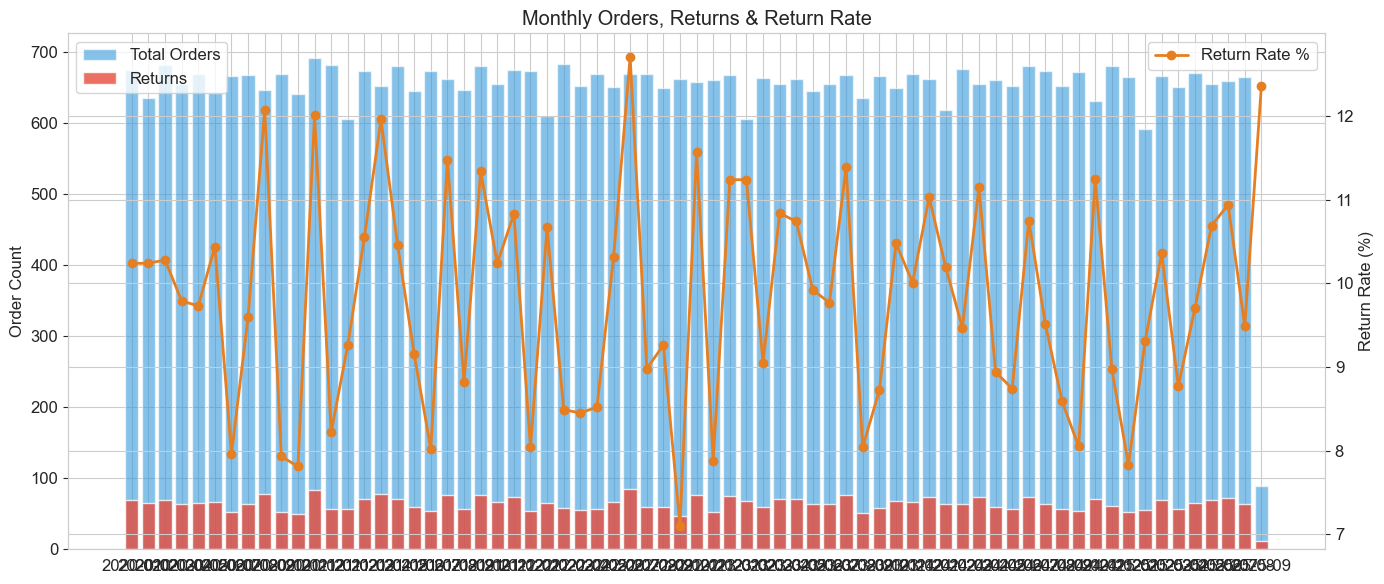

In [37]:
monthly = df.groupby([df['InvoiceDate'].dt.to_period('M')]).agg(
    total_orders=('IsReturn', 'count'),
    returns=('IsReturn', 'sum'),
    return_rate=('IsReturn', 'mean'),
    revenue=('Revenue', 'sum')
).reset_index()
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)
monthly['return_rate'] = (monthly['return_rate'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(monthly['InvoiceDate'], monthly['total_orders'], color='#3498db', alpha=0.6, label='Total Orders')
ax1.bar(monthly['InvoiceDate'], monthly['returns'], color='#e74c3c', alpha=0.8, label='Returns')
ax1.set_ylabel('Order Count')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(monthly['InvoiceDate'], monthly['return_rate'], color='#e67e22', marker='o', linewidth=2, label='Return Rate %')
ax2.set_ylabel('Return Rate (%)')
ax2.legend(loc='upper right')


plt.title('Monthly Orders, Returns & Return Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 10. Day-of-Week & Hour Patterns

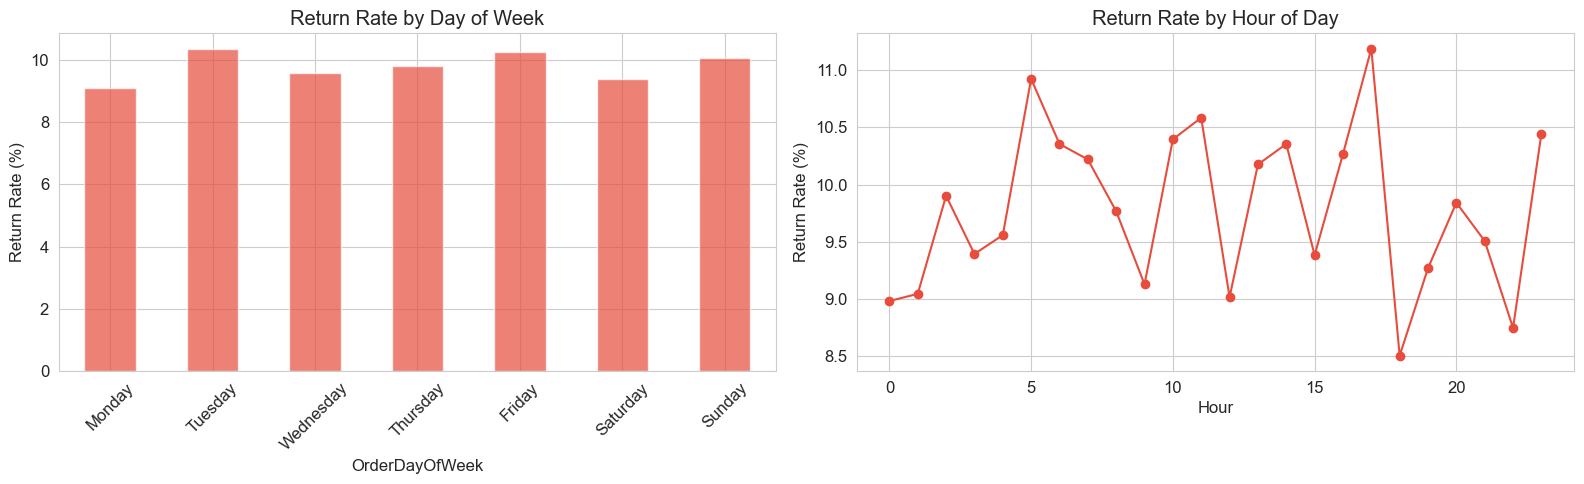

In [13]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_return = df.groupby('OrderDayOfWeek')['IsReturn'].mean().reindex(day_order) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
dow_return.plot(kind='bar', ax=axes[0], color='#e74c3c', alpha=0.7)
axes[0].set_title('Return Rate by Day of Week')
axes[0].set_ylabel('Return Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

hour_return = df.groupby('OrderHour')['IsReturn'].mean() * 100
hour_return.plot(kind='line', ax=axes[1], marker='o', color='#e74c3c')
axes[1].set_title('Return Rate by Hour of Day')
axes[1].set_ylabel('Return Rate (%)')
axes[1].set_xlabel('Hour')

plt.tight_layout()
plt.show()

## 11. Order Priority vs Returns

,Total,Returns,Return Rate
OrderPriority,,,
High,14934,1479,9.90
Low,14898,1454,9.76
Medium,14972,1454,9.71


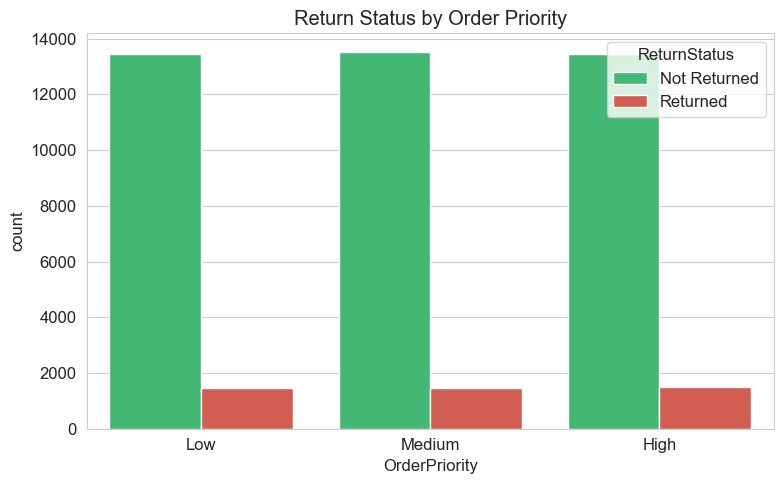

In [14]:
priority_return = df.groupby('OrderPriority')['IsReturn'].agg(['count', 'sum', 'mean'])
priority_return.columns = ['Total', 'Returns', 'Return Rate']
priority_return['Return Rate'] = (priority_return['Return Rate'] * 100).round(2)
display(priority_return)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='OrderPriority', hue='ReturnStatus',
              order=['Low', 'Medium', 'High'], palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Return Status by Order Priority')
plt.tight_layout()
plt.show()

## 12. Shipment Provider vs Returns

,Total,Returns,Return Rate
ShipmentProvider,,,
FedEx,11296,1121,9.92
DHL,11154,1105,9.91
Royal Mail,11196,1110,9.91
UPS,11158,1051,9.42


/var/folders/8b/kbth3kws2b5632g3zxtmp95c0000gn/T/ipykernel_79376/3806445446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ship_return.reset_index(), x='Return Rate', y='ShipmentProvider', palette='Reds_r')


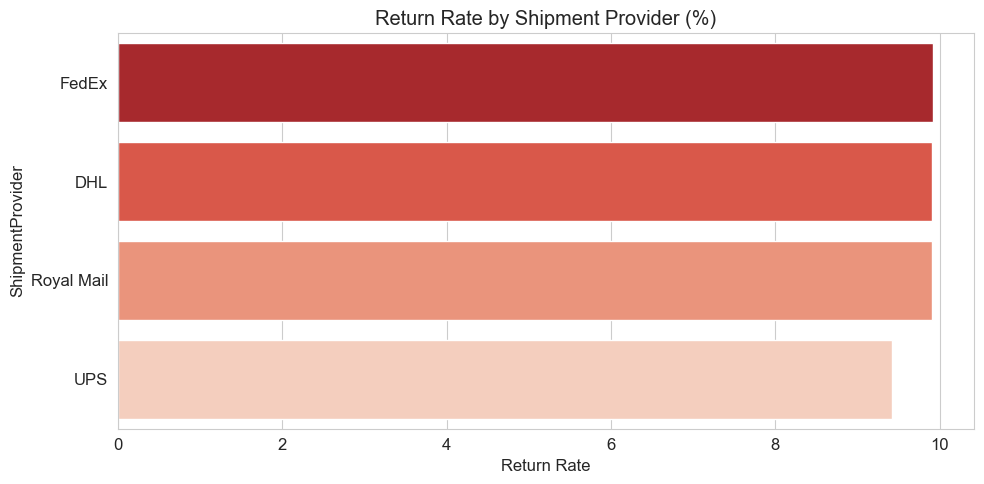

In [38]:
ship_return = df.groupby('ShipmentProvider')['IsReturn'].agg(['count', 'sum', 'mean'])
ship_return.columns = ['Total', 'Returns', 'Return Rate']
ship_return['Return Rate'] = (ship_return['Return Rate'] * 100).round(2)
ship_return = ship_return.sort_values('Return Rate', ascending=False)
display(ship_return)

plt.figure(figsize=(10, 5))
sns.barplot(data=ship_return.reset_index(), x='Return Rate', y='ShipmentProvider', palette='Reds_r')
plt.title('Return Rate by Shipment Provider (%)')
plt.tight_layout()
plt.show()

## 13. Correlation Heatmap

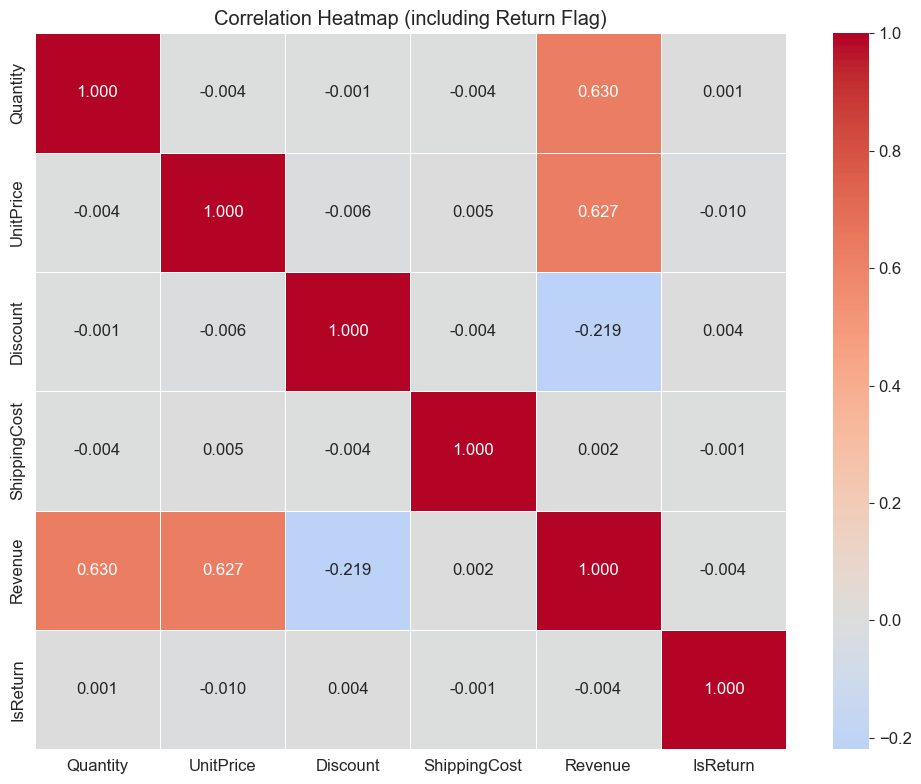

In [16]:
corr_cols = ['Quantity', 'UnitPrice', 'Discount', 'ShippingCost', 'Revenue', 'IsReturn']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (including Return Flag)')
plt.tight_layout()
plt.show()

## 14. Key EDA Takeaways

Summarise your findings after running the notebook:

1. **Return rate:** ~9.79% of all orders are returned (4,387 out of 44,804 orders)
2. **Revenue at risk:** $4,093,258.70 in revenue tied to returned orders (9.7% of total revenue)
3. **Category insight:** Furniture has the highest return rate (10.03%), followed by Stationery (9.88%), Apparel (9.75%), Electronics (9.69%), and Accessories (9.60%). The differences are relatively small across categories.
4. **Geography:** Australia has the highest return rate (10.55%), followed by Germany (10.28%). Spain has the lowest (9.11%). The range is only about 1.4 percentage points across all countries.
5. **Channel effect:** Online (9.74%) vs In-store (9.85%) — virtually no difference in return rates between channels.
6. **Price/Discount:** Returned items have slightly lower average unit price ($49.74 vs $50.72). Discounts and shipping costs are nearly identical between returned and non-returned orders.
7. **Seasonal patterns:** Return rates fluctuate slightly month-to-month, with no extreme spikes. The overall return rate remains consistent around 9-10% throughout the year.
8. **Shipment provider:** FedEx, DHL, and Royal Mail have similar return rates (~9.9%). UPS has a slightly lower rate (9.42%) compared to others.

These observations will be tested statistically in `04_statistical_analysis.ipynb`.